In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
DATA_PATH = "/content/drive/MyDrive/mini_project/datasets/StressLevelDataset.csv"
df = pd.read_csv(DATA_PATH)




In [11]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [12]:
# ---- 2. Basic profile ----
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDescribe:\n", df.describe().T)



Shape: (1100, 21)

Dtypes:
 anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

Missing values:
 anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headac

/tmp/ipykernel_5360/4262525793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stress_level', data=df, palette=['#4C9F70','#F2B134','#D64550'])


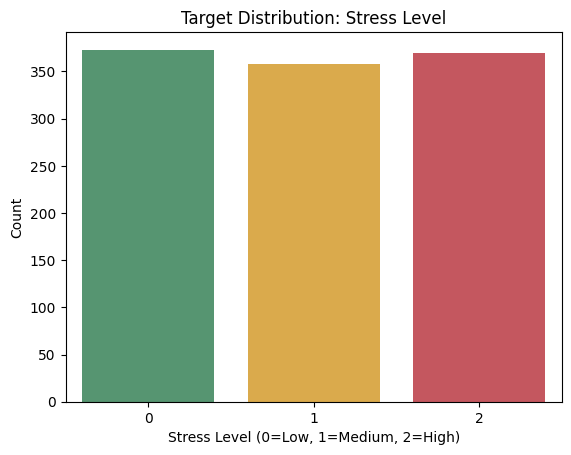

In [13]:
# ---- 3. Target distribution ----
sns.countplot(x='stress_level', data=df, palette=['#4C9F70','#F2B134','#D64550'])
plt.title('Target Distribution: Stress Level')
plt.xlabel('Stress Level (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.show()





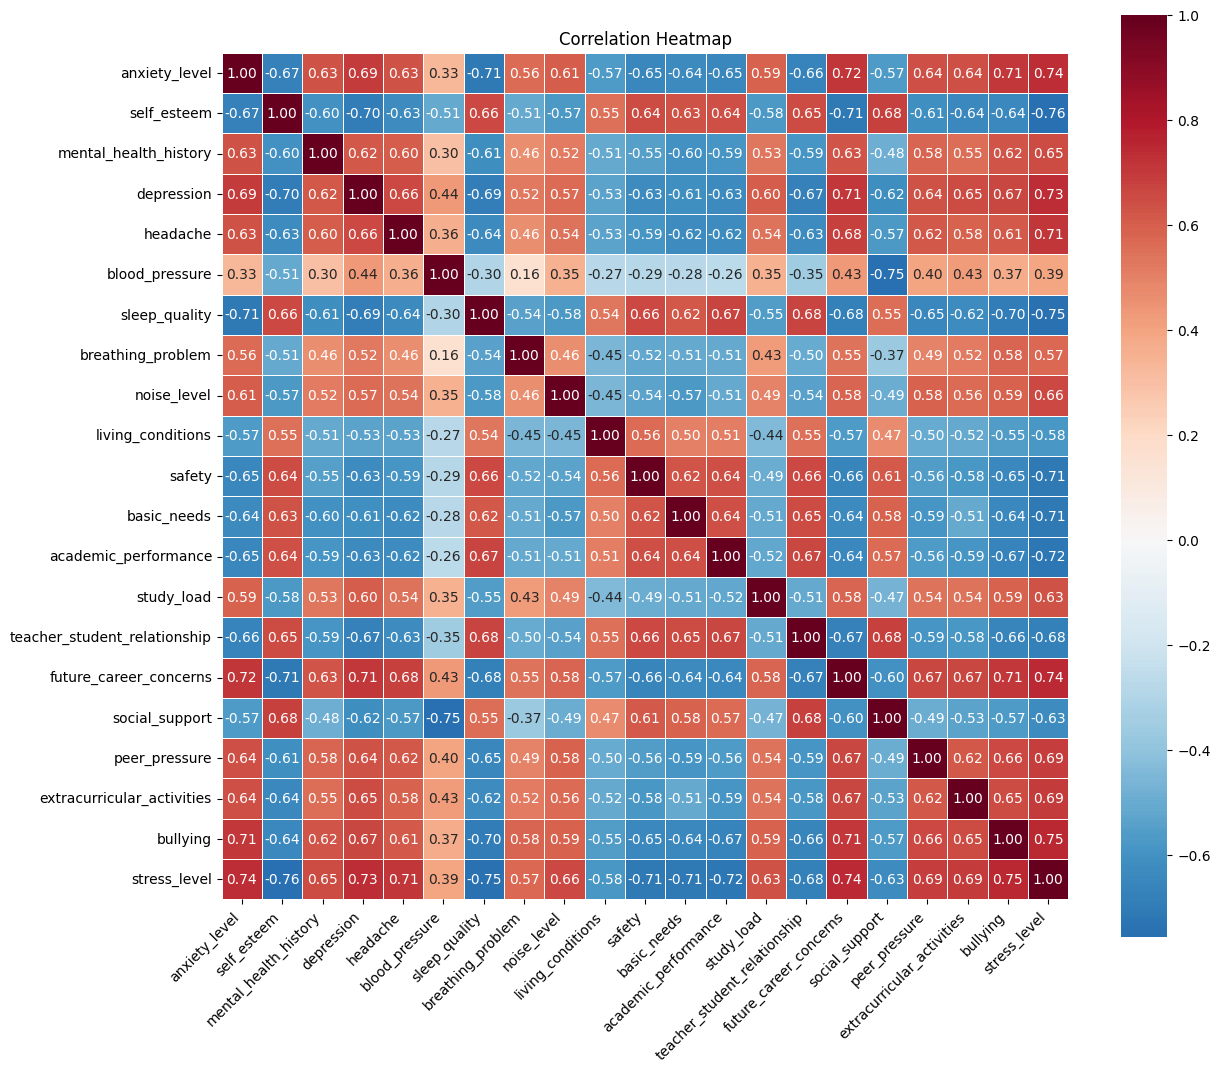


Correlation with stress_level (sorted):
bullying                        0.751162
future_career_concerns          0.742619
anxiety_level                   0.736795
depression                      0.734379
headache                        0.713484
extracurricular_activities      0.692977
peer_pressure                   0.690684
noise_level                     0.663371
mental_health_history           0.648644
study_load                      0.634156
breathing_problem               0.573984
blood_pressure                  0.394200
living_conditions              -0.581723
social_support                 -0.632497
teacher_student_relationship   -0.680163
basic_needs                    -0.708968
safety                         -0.709602
academic_performance           -0.720922
sleep_quality                  -0.749068
self_esteem                    -0.756195
Name: stress_level, dtype: float64


In [14]:
# ---- 4. Correlation heatmap ----
plt.figure(figsize=(13,11))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation with target, sorted
print("\nCorrelation with stress_level (sorted):")
print(corr['stress_level'].drop('stress_level').sort_values(ascending=False))



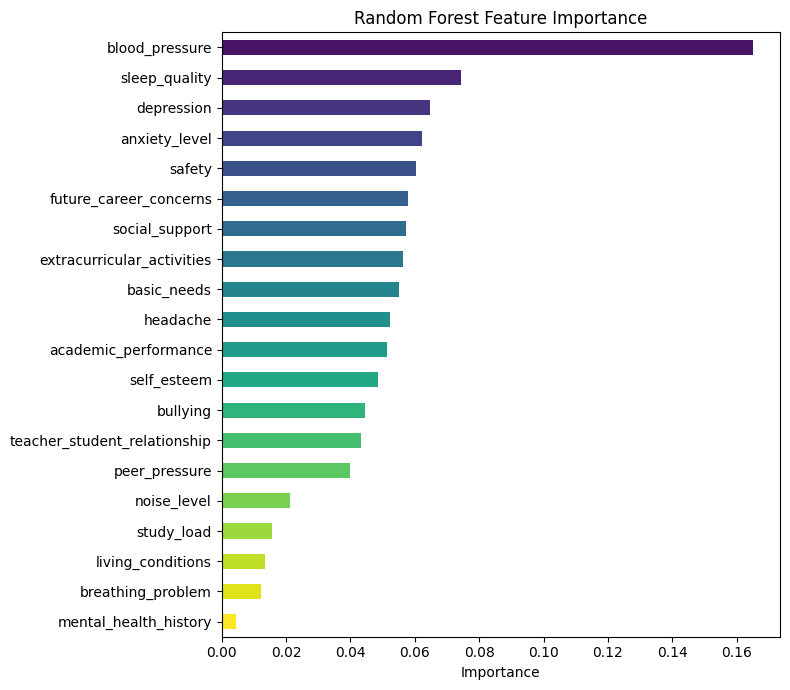

In [15]:
# ---- 5. Feature importance (Random Forest, quick baseline) ----
X = df.drop(columns=['stress_level'])
y = df['stress_level']
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8,7))
importance.plot(kind='barh', color=plt.cm.viridis_r([i/len(importance) for i in range(len(importance))]))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



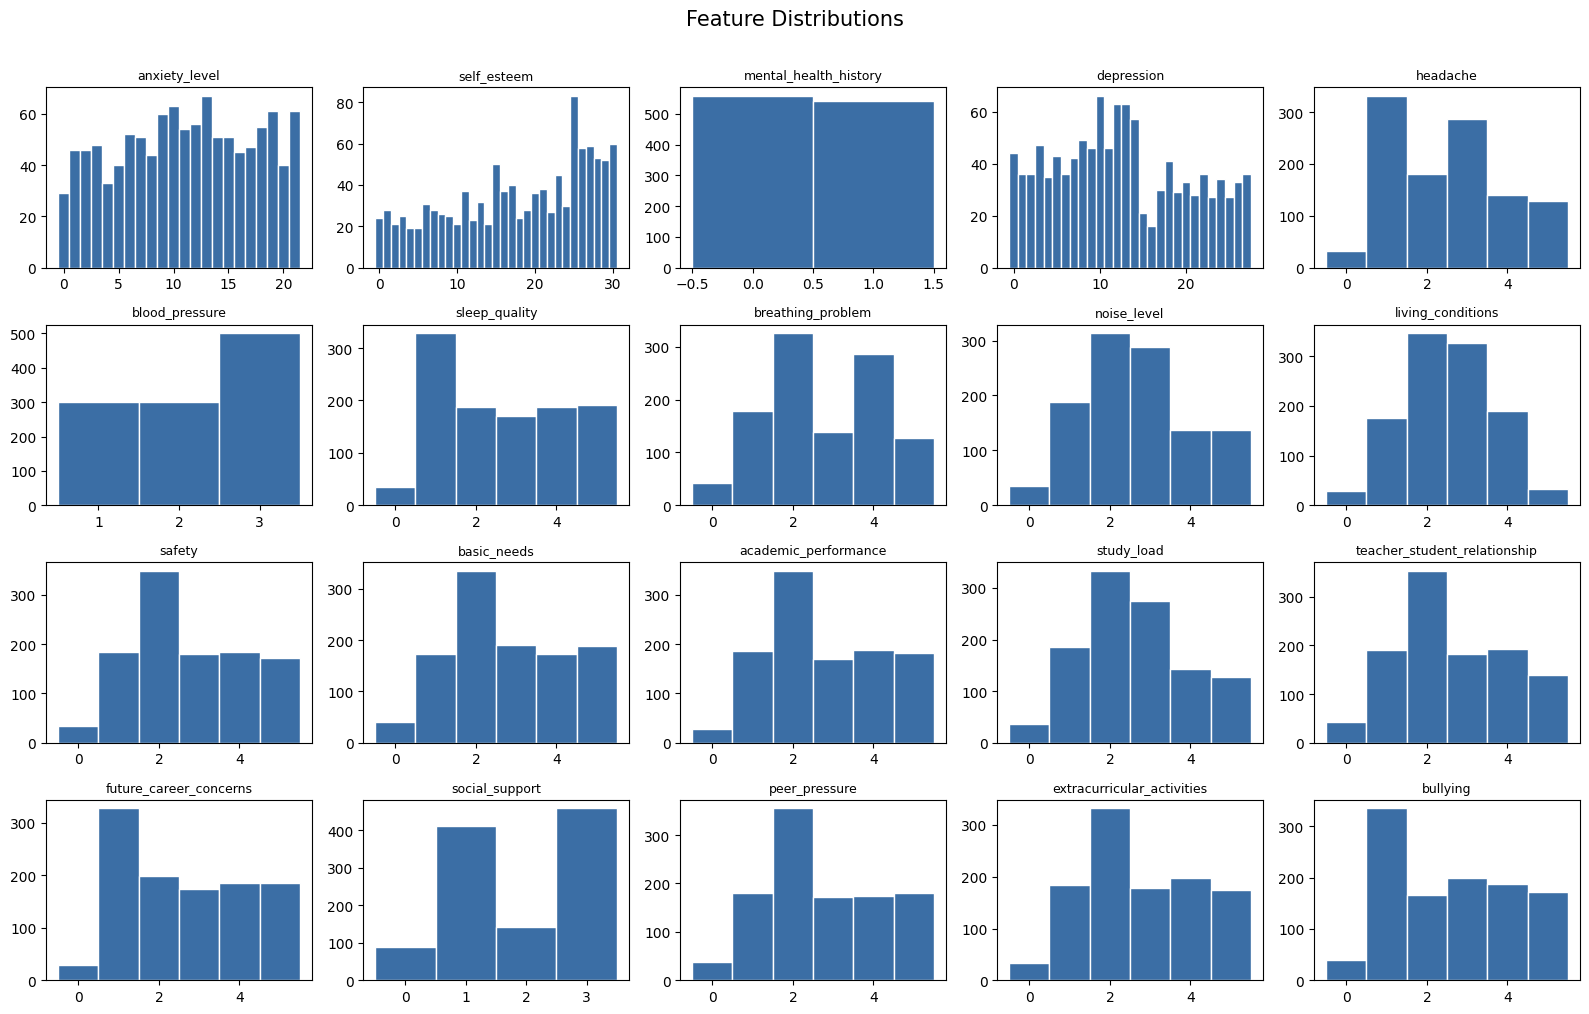

In [16]:
# ---- 6. Feature distributions ----
features = [c for c in df.columns if c != 'stress_level']
fig, axes = plt.subplots(4, 5, figsize=(16,10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=range(int(df[col].min()), int(df[col].max())+2),
                 color='#3b6ea5', edgecolor='white', align='left')
    axes[i].set_title(col, fontsize=9)
for j in range(len(features), len(axes)):
    axes[j].axis('off')
plt.suptitle('Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()



In [17]:
# ---- 7. IQR-based outlier scan (informational — features are bounded ordinal scales) ----
print("\nIQR outlier counts (values outside 1.5*IQR) — informational only,")
print("since features are bounded Likert/ordinal scales, not continuous sensor readings:")
for col in features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if outliers > 0:
        print(f"  {col:30s} flagged={outliers}  (valid extreme category values, not errors)")


IQR outlier counts (values outside 1.5*IQR) — informational only,
since features are bounded Likert/ordinal scales, not continuous sensor readings:
  noise_level                    flagged=173  (valid extreme category values, not errors)
  living_conditions              flagged=62  (valid extreme category values, not errors)
  study_load                     flagged=165  (valid extreme category values, not errors)


In [18]:
!git clone https://github.com/adi-2302/smart-health-support-system.git

Cloning into 'smart-health-support-system'...


In [20]:
%cd smart-health-support-system

/content/smart-health-support-system


In [21]:
!pwd

/content/smart-health-support-system


In [22]:
import os

folders = [
    'data/raw', 'data/processed', 'data/external',
    'notebooks', 'src', 'models',
    'reports/eda_charts', 'reports/model_comparison_results', 'reports/shap_plots',
    'docs'
]

for f in folders:
    os.makedirs(f, exist_ok=True)
    open(f + '/.gitkeep', 'a').close()

print('Done.')
!ls -la

Done.
total 36
drwxr-xr-x 9 root root 4096 Aug 27 12:08 .
drwxr-xr-x 1 root root 4096 Aug 27 12:06 ..
drwxr-xr-x 5 root root 4096 Aug 27 12:08 data
drwxr-xr-x 2 root root 4096 Aug 27 12:08 docs
drwxr-xr-x 7 root root 4096 Aug 27 12:06 .git
drwxr-xr-x 2 root root 4096 Aug 27 12:08 models
drwxr-xr-x 2 root root 4096 Aug 27 12:08 notebooks
drwxr-xr-x 5 root root 4096 Aug 27 12:08 reports
drwxr-xr-x 2 root root 4096 Aug 27 12:08 src


In [24]:

!cp /content/drive/MyDrive/mini_project/datasets/StressLevelDataset.csv data/raw/
!ls data/raw/

StressLevelDataset.csv
